## Problem 1 - Structured Pruning
# Question 1
Runs `prune_model.py` for each pruning fraction: `[0.05, 0.1, 0.2, 0.3, 0.4, 0.5]`  
Settings: `pruning_iter=5`, `finetuning_epochs=5`, `prune_metric=l1`

In [2]:
import subprocess
import sys

pruning_fractions = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5]

for fraction in pruning_fractions:
    print(f'\n========== Pruning fraction: {fraction} ==========', flush=True)
    process = subprocess.Popen(
        [
            sys.executable, 'prune_model.py',
            '--prune_ratio', str(fraction),
            '--prune_metric', 'l1',
            '--pruning_iter', '5',
            '--finetuning_epochs', '5',
            '--model', 'MobilenetV1.pth',
        ],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    for line in process.stdout:
        print(line, end='', flush=True)
    process.wait()
    if process.returncode != 0:
        print(f'[WARNING] Process exited with code {process.returncode}')

print('\nAll experiments complete.')


========== Pruning fraction: 0.05 ==========
C:\Users\rovez\AppData\Roaming\Python\Python311\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")

  Pruning strategy: 1
  Pruning config: metric=l1, ratio=0.05, iters=5, ft_epochs=5
  Baseline parameters: 3,217,226
  Baseline accuracy (before any pruning):


KeyboardInterrupt: 

### Question 2 — Strategy 2
Prune all layers except the **first conv layer**, **first conv block**, and the **last linear layer**.  
Settings: same as Question 1.  
Results saved to `prune_strat_2/`

In [4]:
for fraction in pruning_fractions:
    print(f'\n========== [Strategy 2] Pruning fraction: {fraction} ==========', flush=True)
    process = subprocess.Popen(
        [
            sys.executable, 'prune_model.py',
            '--prune_ratio', str(fraction),
            '--prune_metric', 'l1',
            '--pruning_iter', '5',
            '--finetuning_epochs', '5',
            '--model', 'MobilenetV1.pth',
            '--pruning_strat', '2',
        ],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    for line in process.stdout:
        print(line, end='', flush=True)
    process.wait()
    if process.returncode != 0:
        print(f'[WARNING] Process exited with code {process.returncode}')

print('\nStrategy 2 experiments complete.')


========== [Strategy 2] Pruning fraction: 0.05 ==========
C:\Users\rovez\AppData\Roaming\Python\Python311\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")

  Pruning strategy: 2
  Pruning config: metric=l1, ratio=0.05, iters=5, ft_epochs=5
  Baseline parameters: 3,217,226
  Baseline accuracy (before any pruning):
Test loss: 1.3564 Test accuracy: 77.68 %


--- Pruning Iteration 1/5 ---
  Parameters after pruning: 3,145,589 (97.8% of baseline)
  Accuracy before fine-tuning:
Test loss: 1.3540 Test accuracy: 77.58 %

  Fine-tuning for 5 epoch(s)...
  [Fine-tune (Epoch 1/5)]
    Step [50/391] Loss: 1.4943 Acc: 69.70%
    Step [100/391] Loss: 1.1457 Acc: 71.97%
    Step [150/391] Loss: 1.0091 Acc: 72.92%
    Step [200/391] Loss: 0.9353 Acc: 73.59%
    Step [250/391] L

### Plots — Test Accuracy vs Pruning Fraction & Parameters

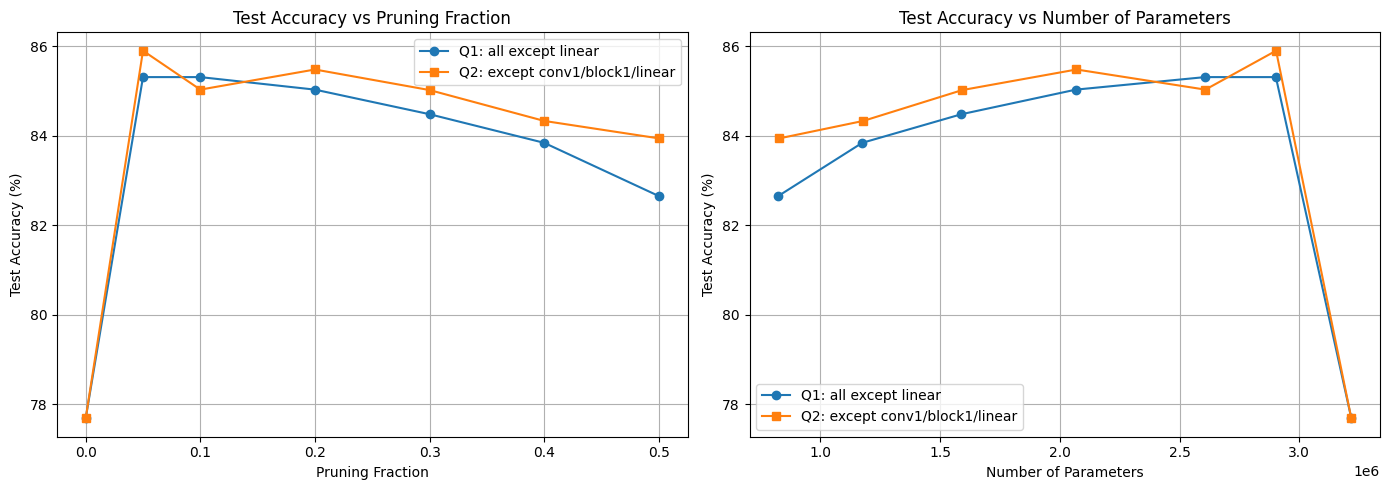

Plot saved to q1_q2_plots.png


In [6]:
import glob
import pandas as pd
import matplotlib.pyplot as plt


def load_results(strat_folder):
    files = glob.glob(f'{strat_folder}/result_*.csv')
    if not files:
        print(f'No result files found in {strat_folder}/')
        return None
    df = pd.concat([pd.read_csv(f) for f in files]).sort_values('pruning_fraction').reset_index(drop=True)
    # Prepend unpruned baseline as pruning_fraction=0
    baseline_row = pd.DataFrame({
        'pruning_fraction': [0.0],
        'final_accuracy':   [df['baseline_accuracy'].iloc[0]],
        'final_params':     [df['baseline_params'].iloc[0]],
        'baseline_accuracy':[df['baseline_accuracy'].iloc[0]],
        'baseline_params':  [df['baseline_params'].iloc[0]],
    })
    return pd.concat([baseline_row, df]).reset_index(drop=True)


df1 = load_results('pruned_models/prune_strat_1')
df2 = load_results('pruned_models/prune_strat_2')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Test accuracy vs pruning fraction
if df1 is not None:
    ax1.plot(df1['pruning_fraction'], df1['final_accuracy'], 'o-', label='Q1: all except linear')
if df2 is not None:
    ax1.plot(df2['pruning_fraction'], df2['final_accuracy'], 's-', label='Q2: except conv1/block1/linear')
ax1.set_xlabel('Pruning Fraction')
ax1.set_ylabel('Test Accuracy (%)')
ax1.set_title('Test Accuracy vs Pruning Fraction')
ax1.legend()
ax1.grid(True)

# Plot 2: Test accuracy vs number of parameters
if df1 is not None:
    ax2.plot(df1['final_params'], df1['final_accuracy'], 'o-', label='Q1: all except linear')
if df2 is not None:
    ax2.plot(df2['final_params'], df2['final_accuracy'], 's-', label='Q2: except conv1/block1/linear')
ax2.set_xlabel('Number of Parameters')
ax2.set_ylabel('Test Accuracy (%)')
ax2.set_title('Test Accuracy vs Number of Parameters')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('q1_q2_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to q1_q2_plots.png')